# 03 - Model Training and Comparison

This notebook trains a RandomForest baseline and a LightGBM comparison model on both the full and conservative feature sets, then selects the best-performing model for optimization.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 34
[LightGBM] [Info] Start training from score 2.994200


/home/shailesh/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 531
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 31
[LightGBM] [Info] Start training from score 2.994200


/home/shailesh/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,feature_set,model,mae,rmse,r2
0,conservative,lightgbm,1.215134,1.417369,-0.006204
1,conservative,random_forest,1.226286,1.424356,-0.016148
2,full,lightgbm,1.215587,1.417592,-0.006521
3,full,random_forest,1.222668,1.421101,-0.011508


,feature,importance
0,Employee_Satisfaction_Score,2053
1,Training_Hours,1666
2,Age,1515
3,Work_Hours_Per_Week,1207
4,Overtime_Hours,1178
5,Team_Size,1036
6,Years_At_Company,714
7,Remote_Work_Frequency,542
8,Education_Level_Bachelor,196
9,Gender_Female,165


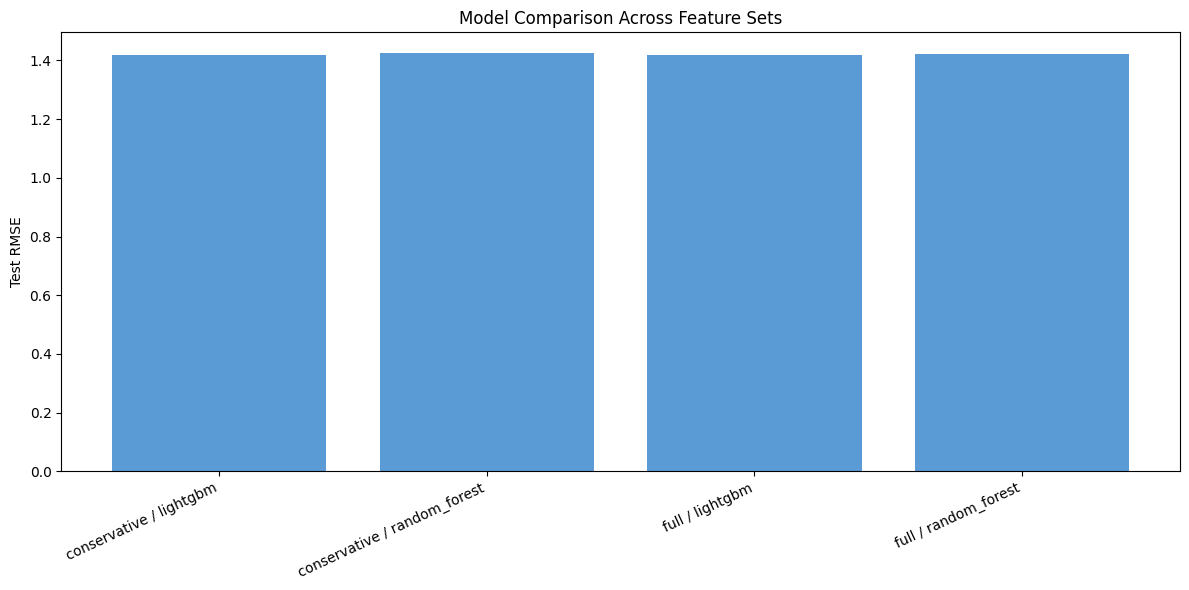

### Model Training Summary
- Best model selected by lowest RMSE: lightgbm on the conservative feature set.
- RandomForest serves as the requested baseline, while LightGBM is the stronger comparison model for this dataset.
- Feature importances are saved for the selected model so the report can explain which variables drive predictions.
- The best model bundle is saved to models/best_model_bundle.joblib for downstream optimization and evaluation.

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

current = Path.cwd().resolve()
candidate_roots = [current, current.parent, current.parent.parent]
ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'smartassign_pipeline.py').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError('Could not locate the repository root.')

sys.path.insert(0, str(ROOT / 'src'))
from smartassign_pipeline import (
    FIGURES_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    ensure_output_directories,
    feature_importance_dataframe,
    fit_and_evaluate_model,
    get_feature_sets,
    load_raw_data,
    save_csv,
    save_json,
    split_train_test,
    summarize_metrics_table,
)

ensure_output_directories()
pd.set_option('display.max_columns', None)

df = load_raw_data()
feature_sets = get_feature_sets(df)

results = []
bundles = {}
for feature_set_name, feature_columns in feature_sets.items():
    train_x, test_x, train_y, test_y = split_train_test(df, feature_columns)
    for model_name in ['random_forest', 'lightgbm']:
        bundle, metrics_frame = fit_and_evaluate_model(
            train_x=train_x,
            test_x=test_x,
            train_y=train_y,
            test_y=test_y,
            model_name=model_name,
            feature_set_name=feature_set_name,
        )
        bundles[(feature_set_name, model_name)] = bundle
        results.append(metrics_frame)

metrics = summarize_metrics_table(pd.concat(results, ignore_index=True))
display(metrics)
save_csv(metrics, RESULTS_DIR / 'model_metrics.csv')

best_row = metrics.sort_values(['rmse', 'mae', 'r2'], ascending=[True, True, False]).iloc[0]
best_bundle = bundles[(best_row['feature_set'], best_row['model'])]
best_bundle.save(MODELS_DIR / 'best_model_bundle.joblib')
save_json(best_row.to_dict(), RESULTS_DIR / 'best_model_metadata.json')

best_importances = feature_importance_dataframe(best_bundle, top_n=20)
display(best_importances)
save_csv(best_importances, RESULTS_DIR / 'best_model_feature_importances.csv')

plt.figure(figsize=(12, 6))
plot_data = metrics.copy()
plot_data['label'] = plot_data['feature_set'] + ' / ' + plot_data['model']
plt.bar(plot_data['label'], plot_data['rmse'], color='#5B9BD5')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Test RMSE')
plt.title('Model Comparison Across Feature Sets')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_model_comparison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

summary_lines = [
    f'Best model selected by lowest RMSE: {best_row["model"]} on the {best_row["feature_set"]} feature set.',
    'RandomForest serves as the requested baseline, while LightGBM is the stronger comparison model for this dataset.',
    'Feature importances are saved for the selected model so the report can explain which variables drive predictions.',
    'The best model bundle is saved to models/best_model_bundle.joblib for downstream optimization and evaluation.',
]
display(Markdown('### Model Training Summary\n' + '\n'.join(f'- {line}' for line in summary_lines)))